In [173]:
import os
# import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt   

# from matplotlib.colors import ListedColormap, BoundaryNorm
%matplotlib inline

# I. Load data

In [ ]:
# Define the path to the data folders relative to the notebook
current_dir = os.getcwd()  # Get the current working directory

# Define paths for data loading
input_path = os.path.join(current_dir, '../data/')

# Define the file name (same for both folders)
file_strict = 'data_choice_evaluation_strict.csv'
file_not_strict = 'data_choice_evaluation_not_strict.csv'

# Load the CSV file
df_strict = pd.read_csv(os.path.join(input_path, file_strict))
df_less_strict = pd.read_csv(os.path.join(input_path, file_not_strict))

# Define path for saving figures
output_path = os.path.join(current_dir, '../results/')

In [175]:
df_strict

,participant_id,frame,question,main,follow_up,choice,evaluation
0,0,loss,Disease,True,NaN,1,22
1,0,loss,Unemployment,True,NaN,0,62
2,0,loss,Painting,True,NaN,1,73
3,0,loss,Virus,True,NaN,1,40
4,1,loss,Disease,True,NaN,2,30
...,...,...,...,...,...,...,...
2134,683,gain,Virus,True,NaN,0,99
2135,686,gain,Disease,True,NaN,0,61
2136,686,gain,Unemployment,True,NaN,1,77
2137,686,gain,Painting,True,NaN,0,70


# II. Percentage of Participants with 0,1,2,3 Neutral Choices

### Calculate the percentage

In [176]:
def count_neutral_choices(data, frame):
    """
    Count the number of participants who chose the neutral option 0, 1, 2, or 3 times.
    
    Parameters:
    data (DataFrame): Input dataframe with choice data (df_strict or df_less_strict)
    
    Returns:
    DataFrame: Count of participants by number of neutral choices made
    """
    # Filter for main task data where neutral option is available
    main_data = data[(data['main'] == True) & (data['frame'] == frame) & (data['question']!='Unemployment')].copy()
    
    # Count neutral choices (choice = 2) per participant
    neutral_counts = main_data.groupby('participant_id')['choice'].apply(
        lambda x: (x == 2).sum()
    ).reset_index(name='neutral_count')
    
    # Count participants for each number of neutral choices (0, 1, 2, 3)
    result = pd.DataFrame({
        'num_neutral_choices': range(4),  # 0, 1, 2, 3
        'count': [
            (neutral_counts['neutral_count'] == 0).sum(),
            (neutral_counts['neutral_count'] == 1).sum(),
            (neutral_counts['neutral_count'] == 2).sum(),
            (neutral_counts['neutral_count'] == 3).sum()
        ]
    })
    
    # Add percentage
    total_participants = main_data['participant_id'].nunique()
    result['percentage'] = (result['count'] / total_participants * 100).round(1)
    
    return result

### Visualize Number of Neutral Choices

#### 1. Individual Condition

In [177]:
def visualize_neutral_choices(data, frame, dataset_type, save_file=False, 
                              color_palette=None, bar_color=None):
    """
    Create a bar chart visualization of neutral choices distribution.
    
    Parameters:
    data (DataFrame): Input dataframe with choice data (df_strict or df_less_strict)
    frame (str): 'gain' or 'loss'
    dataset_type (str): Description of dataset (e.g., 'Strict', 'Less Strict')
    save_file (bool): Whether to save the figure to disk
    color_palette (str, list): Name of seaborn palette or list of colors to use
    bar_color (str): Single color for all bars (overrides color_palette)
    """
    # Count neutral choices
    neutral_counts = count_neutral_choices(data, frame)
    
    # Create a bar chart
    plt.figure(figsize=(6, 4))
    
    # Set colors based on parameters
    if bar_color:
        sns.barplot(x='num_neutral_choices', y='percentage', data=neutral_counts, color=bar_color)
    elif color_palette:
        sns.barplot(x='num_neutral_choices', y='percentage', data=neutral_counts, palette=color_palette)
    else:
        # Default colors based on frame
        default_color = '#D3D3D3' if frame == 'gain' else  '#505050'  # Light Gray for gain, Dark Gray for loss
        sns.barplot(x='num_neutral_choices', y='percentage', data=neutral_counts, color=default_color)
    
    plt.title(f'{dataset_type} Dataset, {frame.capitalize()} Frame', pad=20)
    plt.xlabel('Number of Neutral Choices', fontsize=14)
    plt.ylabel('Percentage of Participants', fontsize=14)
    plt.xticks([0, 1, 2, 3])
    
    # Add percentage labels on top of each bar
    for i, row in neutral_counts.iterrows():
        plt.text(i, row['percentage'] + 1, f"{row['percentage']}%", 
                ha='center', fontweight='bold')
    
    plt.ylim(0, 70)
    # Remove top and right spines
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    # Save the figure if required
    if save_file:
        filename = f'neutral_choices_distribution_{dataset_type.lower().replace(" ", "_")}_{frame}_frame.png'
        plt.savefig(os.path.join(output_path, filename), bbox_inches='tight', dpi=300)
    
    # Show the figure after saving to prevent clearing the content
    plt.show()
        
    return neutral_counts

##### 1. Strict Dataset

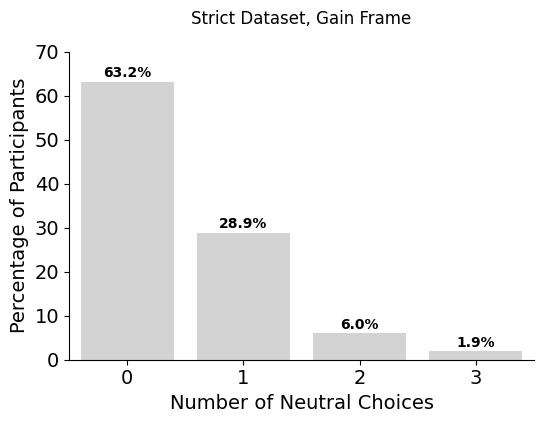

,num_neutral_choices,count,percentage
0,0,168,63.2
1,1,77,28.9
2,2,16,6.0
3,3,5,1.9


In [178]:
# Gain Frame
visualize_neutral_choices(df_strict, 'gain', 'Strict', save_file=True)

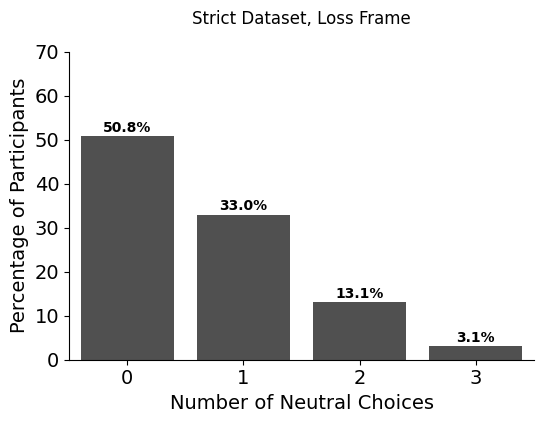

,num_neutral_choices,count,percentage
0,0,97,50.8
1,1,63,33.0
2,2,25,13.1
3,3,6,3.1


In [179]:
# Loss Frame
visualize_neutral_choices(df_strict, 'loss', 'Strict', save_file=True)

##### 2. Less Strict Dataset

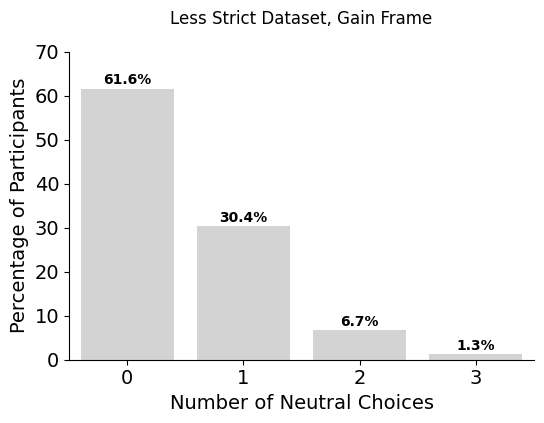

,num_neutral_choices,count,percentage
0,0,231,61.6
1,1,114,30.4
2,2,25,6.7
3,3,5,1.3


In [180]:
# Gain
visualize_neutral_choices(df_less_strict, 'gain', 'Less Strict', save_file=True)



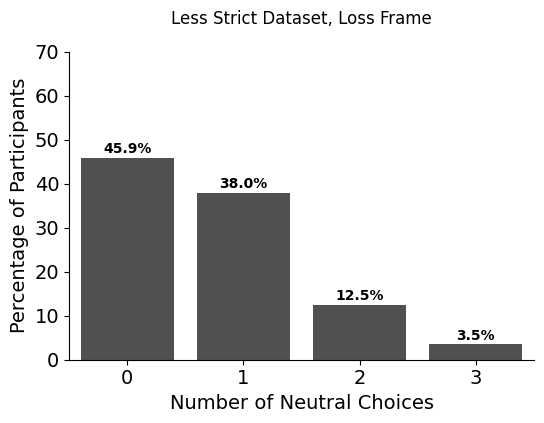

,num_neutral_choices,count,percentage
0,0,117,45.9
1,1,97,38.0
2,2,32,12.5
3,3,9,3.5


In [181]:
# Loss Frame
visualize_neutral_choices(df_less_strict, 'loss', 'Less Strict', save_file=True)


#### 2. Combined Visualization

In [182]:
def visualize_all_neutral_choices(df_strict, df_less_strict, save_file=False):
    """
    Create a 2x2 grid of bar charts showing neutral choice distributions
    for all combinations of frame (gain/loss) and dataset (strict/less strict).
    
    Parameters:
    df_strict (DataFrame): Strict dataset
    df_less_strict (DataFrame): Less strict dataset
    save_file (bool): Whether to save the figure to disk
    """
    # Create figure with 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    
    # Define datasets and frames
    datasets = [df_strict, df_less_strict]
    dataset_names = ['Strict', 'Less Strict']
    frames = ['gain', 'loss']
    
    # Define colors for each frame
    colors = {'gain': '#D3D3D3', 'loss': '#505050'}  # Light Gray for gain, Dark Gray for loss
    
    # Create each subplot
    for row, dataset in enumerate(datasets):
        for col, frame in enumerate(frames):
            ax = axes[row, col]
            
            # Count neutral choices for this dataset and frame
            neutral_counts = count_neutral_choices(dataset, frame)
            
            # Create bar plot
            sns.barplot(
                x='num_neutral_choices', 
                y='percentage', 
                data=neutral_counts, 
                color=colors[frame],
                ax=ax
            )
            
            # Set subplot title with left alignment
            ax.set_title(f'{dataset_names[row]} Dataset, {frame.capitalize()} Frame', 
                        pad=20, 
                        fontsize=18, 
                        loc='left',
                        x=-0.15,
                        fontweight='bold')  # Move title more to the left, align with y label
            
            # Set x-label only for bottom row
            if row == 1:
                ax.set_xlabel('Number of Neutral Choices', fontsize=16, fontweight='bold')
            else:
                ax.set_xlabel('')
            
            # Set y-label only for left column
            if col == 0:
                ax.set_ylabel('Percentage of Participants', fontsize=16, fontweight='bold')
            else:
                ax.set_ylabel('')
            
            # Set x-ticks
            ax.set_xticks([0, 1, 2, 3])
            
            # Add percentage labels on top of each bar
            for i, bar_row in neutral_counts.iterrows():
                ax.text(
                    i, 
                    bar_row['percentage'] + 1, 
                    f"{bar_row['percentage']}%", 
                    ha='center', 
                    fontweight='bold',
                    fontsize=16
                )
            
            # Set y-limit
            ax.set_ylim(0, 70)
            
            # Remove top and right spines
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            
            # Set font sizes
            ax.tick_params(axis='both', labelsize=16)
    
    # REMOVE THIS LINE: fig.tight_layout(pad=5.0)  
    
    # Adjust spacing with greater control
    plt.subplots_adjust(
        hspace=0.35,  # Horizontal space between subplots
        wspace=0.3,  # Vertical space between subplots
        top=0.92,    # Top margin
        bottom=0.08, # Bottom margin
        left=0.08,   # Left margin
        right=0.92   # Right margin
    )
    
    # REMOVE THIS LINE: plt.tight_layout()
    
    # Save the figure if required
    if save_file:
        filename = 'neutral_choices_distribution_combined.png'
        plt.savefig(os.path.join(output_path, filename), bbox_inches='tight', dpi=300)
    
    # Show the figure
    plt.show()
    
    return fig

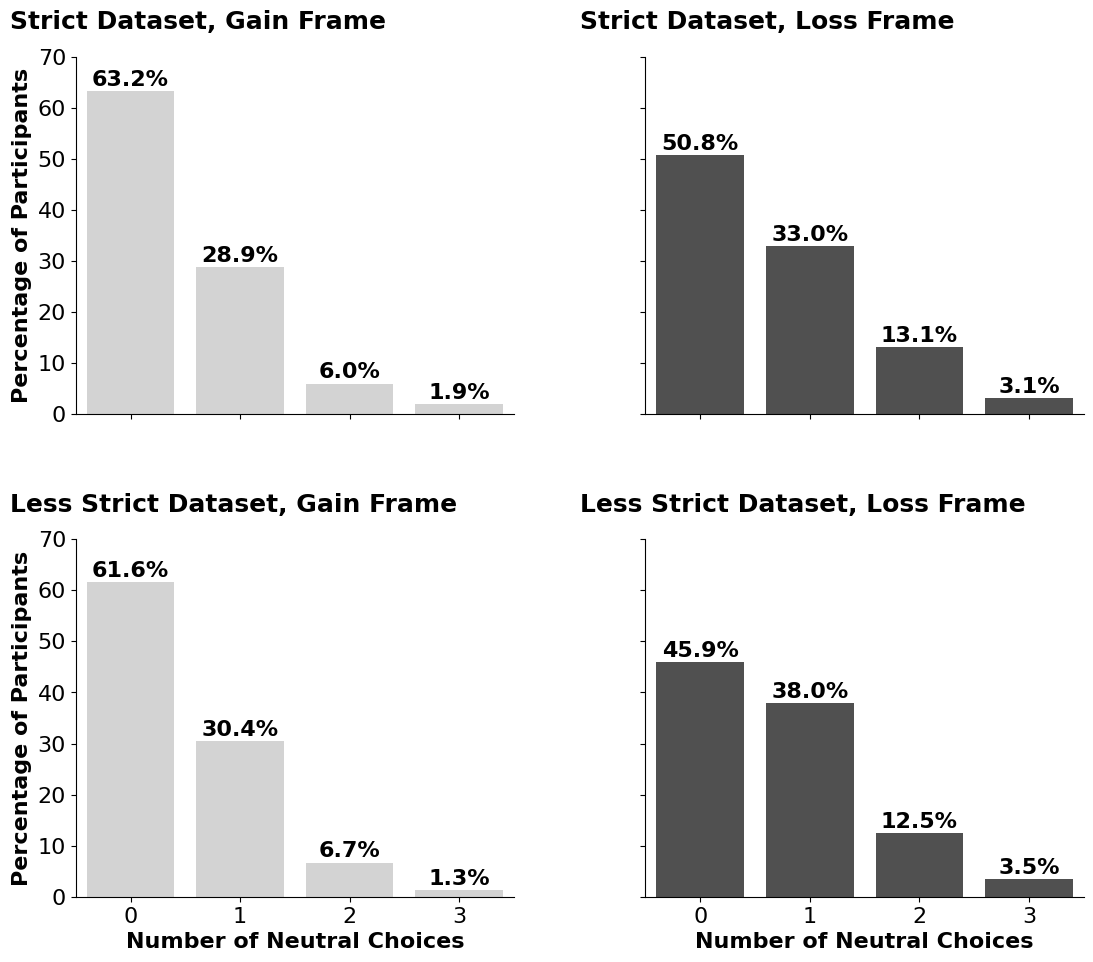

In [183]:
# Create the combined visualization
fig = visualize_all_neutral_choices(df_strict, df_less_strict, save_file=True)

# III. Accuracy in Control Question

In [184]:
def check_control_question_accuracy(data, frame):
    """
    Check the accuracy of the control question in the dataset.
    
    Parameters:
    data (DataFrame): Input dataframe with control question data
    
    Returns:
    DataFrame: Count of correct and incorrect answers
    """
    # Filter for control question responses
    control_data = data[(data['question'] == 'Unemployment') & (data['main'] == True) & (data['frame'] == frame)].copy()

    # Count correct and incorrect answers
    if frame == 'gain':
        accuracy_counts = len(control_data[control_data['choice'] == 1])
    else:
        accuracy_counts = len(control_data[control_data['choice'] == 0])
    
    accuracy = accuracy_counts/len(control_data)
    return accuracy,accuracy_counts

### 1. Strict Dataset

In [185]:
# Gain
accuracy_strict_gain = check_control_question_accuracy(df_strict, 'gain')
print(f"Control question accuracy under gain frame (strict dataset): {accuracy_strict_gain[0]:.2f} \n accuracy counts: {accuracy_strict_gain[1]}")

Control question accuracy under gain frame (strict dataset): 0.69 
 accuracy counts: 183


In [186]:
# Loss
accuracy_strict_loss = check_control_question_accuracy(df_strict, 'loss')
print(f"Control question accuracy under loss frame (strict dataset): {accuracy_strict_loss[0]:.2f} \n accuracy counts: {accuracy_strict_loss[1]}")

Control question accuracy under loss frame (strict dataset): 0.72 
 accuracy counts: 137


### 2. Less Strict Dataset

In [187]:
# Gain
accuracy_less_strict_gain = check_control_question_accuracy(df_less_strict, 'gain')
print(f"Control question accuracy under gain frame (less strict dataset): {accuracy_less_strict_gain[0]:.2f} \n accuracy counts: {accuracy_less_strict_gain[1]}")

Control question accuracy under gain frame (less strict dataset): 0.64 
 accuracy counts: 241


In [188]:
# Loss
accuracy_less_strict_loss = check_control_question_accuracy(df_less_strict, 'loss')
print(f"Control question accuracy under loss frame (less strict dataset): {accuracy_less_strict_loss[0]:.2f} \n accuracy counts: {accuracy_less_strict_loss[1]}")

Control question accuracy under loss frame (less strict dataset): 0.69 
 accuracy counts: 175
